In [268]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"
DATA_EXTERNAL = BASE_DIR / "data" / "external"

# Dataset final
df = pd.read_csv(
    DATA_PROCESSED / "dataset_final_tfm.csv"
)

# Distancias
distancias = pd.read_csv(
    DATA_EXTERNAL / "distancia_pueblos.csv",
    sep=";"
)

print(df.shape)
print(distancias.shape)

(128, 42)
(168, 3)


In [269]:
precios = pd.read_csv(
    DATA_EXTERNAL / "precios_municipios_granada_2026.csv"
)

precios.head()

,municipio,comarca,precio_venta_eur_m2,precio_alquiler_eur_m2_mes,fuente,fecha
0,Sierra Nevada,Sierra Nevada,3081,NaN,Idealista,2026-05
1,Almuñécar,Costa Tropical,3067,10.8,Idealista,2026-05
2,Granada Capital,Área Metropolitana,2645,10.7,Idealista,2026-05
3,Salobreña,Costa Tropical,2173,9.1,Idealista,2026-05
4,Armilla,Área Metropolitana,2144,9.0,Idealista,2026-05


In [270]:
precios["municipio_merge"] = (
    precios["municipio"]
    .apply(limpiar_texto)
)

In [271]:
df_v3 = df_v3.merge(
    precios[
        [
            "municipio_merge",
            "precio_venta_eur_m2"
        ]
    ],
    on="municipio_merge",
    how="left"
)

In [272]:
df_v3.columns.tolist()

['codigo_ine',
 'municipio',
 'poblacion_2025',
 'superficie_residencial_m2',
 'n_poligonos',
 'superficie_media_poligono',
 'precio_m2',
 'fuente',
 'anio',
 'superficie_residencial_ha',
 'cluster',
 'suelo_por_habitante',
 'score_poblacion',
 'score_superficie',
 'score_suelo_hab',
 'coopscore_v1',
 'oportunidad',
 'log_poblacion',
 'score_log_poblacion',
 'coopscore_v2',
 'PCA1',
 'PCA2',
 'objetivo_ml',
 'densidad_residencial',
 'municipio_merge',
 'distancia_capital_km',
 'distancia_costa_km',
 'score_capital',
 'score_costa',
 'score_capital_norm',
 'score_costa_norm',
 'coopscore_v3',
 'factor_poblacion',
 'coopscore_v4',
 'score_precio',
 'coopscore_v5',
 'score_litoral',
 'coopscore_v6',
 'score_n_poligonos',
 'IVU',
 'IVEC',
 'perfil_municipio',
 'precio_venta_eur_m2']

In [273]:
import pandas as pd

df = pd.read_csv(DATA_PROCESSED / "dataset_maestro_granada_v2.csv")

print(df.shape)

df.columns.tolist()

(128, 9)


['codigo_ine',
 'municipio',
 'poblacion_2025',
 'superficie_residencial_m2',
 'n_poligonos',
 'superficie_media_poligono',
 'precio_m2',
 'fuente',
 'anio']

In [274]:
precios = pd.read_csv(
    DATA_EXTERNAL / "precios_municipios_granada_2026.csv"
)

print(precios.shape)

precios.columns.tolist()

(42, 6)


['municipio',
 'comarca',
 'precio_venta_eur_m2',
 'precio_alquiler_eur_m2_mes',
 'fuente',
 'fecha']

In [275]:
df = pd.read_csv(
    DATA_PROCESSED / "dataset_modelado_v2.csv"
)

print(df.shape)

df.head()

(128, 24)


,codigo_ine,municipio,poblacion_2025,superficie_residencial_m2,n_poligonos,superficie_media_poligono,precio_m2,fuente,anio,superficie_residencial_ha,...,score_suelo_hab,coopscore_v1,oportunidad,log_poblacion,score_log_poblacion,coopscore_v2,PCA1,PCA2,objetivo_ml,densidad_residencial
0,18905,"Gabias, Las",23584,3.682035e+06,1,3.682035e+06,NaN,NaN,NaN,368.203480,...,0.098990,54.727024,Alta,10.068366,0.836062,70.917217,3.626685,-2.811868,0.717369,3.682035e+06
1,18089,Guadix,18881,3.460928e+06,7,4.944182e+05,NaN,NaN,NaN,346.092770,...,0.117566,50.499792,Media,9.845964,0.796918,67.698749,4.081036,-0.779808,0.684117,4.944182e+05
2,18022,Atarfe,20914,3.364040e+06,1,3.364040e+06,1369.0,Idealista,2026.0,336.403955,...,0.102221,50.001496,Media,9.948222,0.814916,67.107310,3.163160,-2.539686,0.675978,3.364040e+06
3,18029,Benamaurel,2235,3.295178e+06,9,3.661309e+05,NaN,NaN,NaN,329.517829,...,1.000000,66.788439,Alta,7.712444,0.421410,73.152211,2.949366,0.583649,0.755160,3.661309e+05
4,18003,Albolote,19768,2.949836e+06,1,2.949836e+06,NaN,NaN,NaN,294.983553,...,0.094273,44.654150,Media,9.891870,0.804998,62.545834,2.746676,-2.284150,0.625193,2.949836e+06


In [276]:
import unicodedata

def limpiar_texto(texto):
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )
    return texto

# Normalizar nombres
df["municipio_merge"] = df["municipio"].apply(limpiar_texto)
distancias["municipio_merge"] = distancias["localidad"].apply(limpiar_texto)

# Correcciones por diferencias INE / CSV distancias
correcciones = {
    "gabias, las": "las gabias",
    "valle, el": "el valle",
    "malaha, la": "la malaha",
    "calahorra, la": "la calahorra",
    "peza, la": "la peza",
}

df["municipio_merge"] = df["municipio_merge"].replace(correcciones)

# Renombrar columnas
distancias = distancias.rename(
    columns={
        "Distancia en Kms Capital": "distancia_capital_km",
        "Distancia en kms a la costa": "distancia_costa_km"
    }
)

# Borrar columnas previas si existían
df_base = df.drop(
    columns=["distancia_capital_km", "distancia_costa_km"],
    errors="ignore"
)

# Merge limpio
df_v3 = df_base.merge(
    distancias[
        [
            "municipio_merge",
            "distancia_capital_km",
            "distancia_costa_km"
        ]
    ],
    on="municipio_merge",
    how="left"
)

print("Sin distancia capital:", df_v3["distancia_capital_km"].isna().sum())
print("Sin distancia costa:", df_v3["distancia_costa_km"].isna().sum())

display(
    df_v3[df_v3["distancia_capital_km"].isna()]
    [["municipio", "municipio_merge"]]
)

Sin distancia capital: 7
Sin distancia costa: 8


,municipio,municipio_merge
43,Valderrubio,valderrubio
71,Torre-Cardela,torre-cardela
93,Domingo Pérez de Granada,domingo perez de granada
95,Dehesas Viejas,dehesas viejas
106,Játar,jatar
109,Fornes,fornes
124,Torrenueva Costa,torrenueva costa


In [277]:
# Imputación conservadora para los pocos municipios sin distancia
df_v3["distancia_capital_km"] = df_v3["distancia_capital_km"].fillna(
    df_v3["distancia_capital_km"].median()
)

df_v3["distancia_costa_km"] = df_v3["distancia_costa_km"].fillna(
    df_v3["distancia_costa_km"].median()
)

In [278]:
df_v3["score_capital"] = 1 / (1 + df_v3["distancia_capital_km"])
df_v3["score_costa"] = 1 / (1 + df_v3["distancia_costa_km"])

In [279]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_v3["score_capital_norm"] = scaler.fit_transform(df_v3[["score_capital"]])
df_v3["score_costa_norm"] = scaler.fit_transform(df_v3[["score_costa"]])

df_v3["coopscore_v3"] = (
    df_v3["score_superficie"] * 0.30 +
    df_v3["score_log_poblacion"] * 0.25 +
    df_v3["score_suelo_hab"] * 0.20 +
    df_v3["score_capital_norm"] * 0.15 +
    df_v3["score_costa_norm"] * 0.10
) * 100

In [280]:
df_v3[
    [
        "municipio",
        "poblacion_2025",
        "distancia_capital_km",
        "distancia_costa_km",
        "coopscore_v3"
    ]
].sort_values("coopscore_v3", ascending=False).head(20)

,municipio,poblacion_2025,distancia_capital_km,distancia_costa_km,coopscore_v3
0,"Gabias, Las",23584,9.05,189.0,60.625522
3,Benamaurel,2235,109.41,36.8,57.832472
2,Atarfe,20914,10.45,108.3,56.583843
4,Albolote,19768,9.78,71.1,53.274086
1,Guadix,18881,52.61,91.1,51.569277
9,Armilla,25300,8.12,142.7,47.096802
5,Loja,20951,53.49,103.9,46.469299
19,Maracena,22294,4.34,43.6,46.342346
11,Churriana de la Vega,16878,7.81,60.6,44.610657
6,Salobreña,12760,67.63,7.6,43.314569


In [281]:
df_v3["factor_poblacion"] = np.where(
    df_v3["poblacion_2025"] < 5000,
    0.75,
    1
)

df_v3["coopscore_v4"] = (
    df_v3["coopscore_v3"]
    * df_v3["factor_poblacion"]
)

In [282]:
df_v3[
    [
        "municipio",
        "poblacion_2025",
        "coopscore_v4"
    ]
].sort_values(
    "coopscore_v4",
    ascending=False
).head(20)

,municipio,poblacion_2025,coopscore_v4
0,"Gabias, Las",23584,60.625522
2,Atarfe,20914,56.583843
4,Albolote,19768,53.274086
1,Guadix,18881,51.569277
9,Armilla,25300,47.096802
5,Loja,20951,46.469299
19,Maracena,22294,46.342346
11,Churriana de la Vega,16878,44.610657
3,Benamaurel,2235,43.374354
6,Salobreña,12760,43.314569


In [283]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_v3["score_precio"] = np.nan

mask = df_v3["precio_m2"].notna()

df_v3.loc[mask, "score_precio"] = scaler.fit_transform(
    df_v3.loc[mask, ["precio_m2"]]
)

In [284]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

mask = df_v3["precio_venta_eur_m2"].notna()

df_v3["score_precio"] = np.nan

df_v3.loc[mask, "score_precio"] = scaler.fit_transform(
    df_v3.loc[mask, ["precio_venta_eur_m2"]]
)

KeyError: 'precio_venta_eur_m2'

In [ ]:
df_v3["score_precio"] = (
    df_v3["score_precio"]
    .fillna(df_v3["score_precio"].median())
)

In [ ]:
df_v3["coopscore_v5"] = (

    df_v3["score_superficie"] * 0.25 +

    df_v3["score_log_poblacion"] * 0.20 +

    df_v3["score_suelo_hab"] * 0.15 +

    df_v3["score_capital_norm"] * 0.15 +

    df_v3["score_costa_norm"] * 0.10 +

    df_v3["score_precio"] * 0.15

) * 100

In [ ]:
df_v3[
    [
        "municipio",
        "poblacion_2025",
        "precio_m2",
        "coopscore_v5"
    ]
].sort_values(
    "coopscore_v5",
    ascending=False
).head(25)

,municipio,poblacion_2025,precio_m2,coopscore_v5
0,"Gabias, Las",23584,NaN,56.300093
2,Atarfe,20914,1369.0,52.002250
3,Benamaurel,2235,NaN,51.604421
4,Albolote,19768,NaN,50.129119
9,Armilla,25300,2120.0,49.270771
1,Guadix,18881,NaN,47.649132
19,Maracena,22294,NaN,45.759713
12,Almuñécar,27544,2999.0,44.918964
6,Salobreña,12760,2078.0,44.685451
11,Churriana de la Vega,16878,NaN,43.269007


In [ ]:
# ==========================================================
# SCORE LITORAL
# ==========================================================

df_v3["score_litoral"] = 0

costa = [
    "Almuñécar",
    "Salobreña",
    "Motril",
    "Polopos",
    "Gualchos",
    "Rubite",
    "Sorvilán",
    "Lújar"
]

influencia_alta = [
    "Vélez de Benaudalla",
    "Molvízar",
    "Jete",
    "Otívar",
    "Ítrabo",
    "Lentegí",
    "Los Guájares"
]

df_v3.loc[
    df_v3["municipio"].isin(costa),
    "score_litoral"
] = 1

df_v3.loc[
    df_v3["municipio"].isin(influencia_alta),
    "score_litoral"
] = 0.75

C:\Users\pepetorres\AppData\Local\Temp\ipykernel_28548\949474821.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_v3.loc[


In [ ]:
# ==========================================================
# COOPSCORE V6
# ==========================================================

df_v3["coopscore_v6"] = (

    df_v3["score_superficie"] * 0.25 +

    df_v3["score_log_poblacion"] * 0.20 +

    df_v3["score_suelo_hab"] * 0.15 +

    df_v3["score_capital_norm"] * 0.25 +

    df_v3["score_litoral"] * 0.15

) * 100

In [ ]:
df_v3[
    [
        "municipio",
        "coopscore_v6"
    ]
].sort_values(
    "coopscore_v6",
    ascending=False
).head(20)

,municipio,coopscore_v6
0,"Gabias, Las",56.101276
2,Atarfe,51.873899
19,Maracena,50.230449
6,Salobreña,49.929300
4,Albolote,49.472101
3,Benamaurel,46.202831
9,Armilla,45.589540
12,Almuñécar,45.104343
11,Churriana de la Vega,43.732634
1,Guadix,42.933646


In [ ]:
# ==========================================================
# NORMALIZACIÓN NÚMERO DE POLÍGONOS
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_v3["score_n_poligonos"] = scaler.fit_transform(
    df_v3[["n_poligonos"]]
)

In [ ]:
# ==========================================================
# IVU
# ==========================================================

df_v3["IVU"] = (

    df_v3["score_superficie"] * 0.50 +

    df_v3["score_suelo_hab"] * 0.30 +

    (1 - df_v3["score_n_poligonos"]) * 0.20

) * 100

In [ ]:
df_v3["score_precio"] = (
    df_v3["score_precio"]
    .fillna(
        df_v3["score_precio"].median()
    )
)

In [ ]:
# ==========================================================
# IVEC
# ==========================================================

df_v3["IVEC"] = (

    df_v3["score_precio"] * 0.40 +

    df_v3["score_log_poblacion"] * 0.30 +

    df_v3["score_capital_norm"] * 0.20 +

    df_v3["score_litoral"] * 0.10

) * 100

In [ ]:
df_v3[
    [
        "municipio",
        "coopscore_v6",
        "IVU",
        "IVEC"
    ]
].sort_values(
    "coopscore_v6",
    ascending=False
).head(20)

,municipio,coopscore_v6,IVU,IVEC
0,"Gabias, Las",56.101276,72.969703,49.664214
2,Atarfe,51.873899,68.716851,45.605500
19,Maracena,50.230449,34.081099,59.051062
6,Salobreña,49.929300,58.378387,57.066760
4,Albolote,49.472101,62.812622,47.988810
3,Benamaurel,46.202831,85.819401,27.244904
9,Armilla,45.589540,46.430599,61.888424
12,Almuñécar,45.104343,29.434514,76.619200
11,Churriana de la Vega,43.732634,46.724376,49.443105
1,Guadix,42.933646,63.835852,39.568974


In [ ]:
df_v3["perfil_municipio"] = "Equilibrado"

In [ ]:
df_v3.loc[
    (df_v3["IVU"] >= 60) &
    (df_v3["IVEC"] < 40),
    "perfil_municipio"
] = "Potencial Urbanístico"

In [ ]:
df_v3.loc[
    (df_v3["IVEC"] >= 60) &
    (df_v3["IVU"] < 40),
    "perfil_municipio"
] = "Potencial Económico"

In [ ]:
df_v3.loc[
    (df_v3["IVEC"] >= 50) &
    (df_v3["IVU"] >= 50),
    "perfil_municipio"
] = "Alta Prioridad"

In [ ]:
df_v3[
    ["municipio","coopscore_v6","IVU","IVEC","perfil_municipio"]
].sort_values(
    "coopscore_v6",
    ascending=False
).head(15)

,municipio,coopscore_v6,IVU,IVEC,perfil_municipio
0,"Gabias, Las",56.101276,72.969703,49.664214,Equilibrado
2,Atarfe,51.873899,68.716851,45.605500,Equilibrado
19,Maracena,50.230449,34.081099,59.051062,Equilibrado
6,Salobreña,49.929300,58.378387,57.066760,Alta Prioridad
4,Albolote,49.472101,62.812622,47.988810,Equilibrado
3,Benamaurel,46.202831,85.819401,27.244904,Potencial Urbanístico
9,Armilla,45.589540,46.430599,61.888424,Equilibrado
12,Almuñécar,45.104343,29.434514,76.619200,Potencial Económico
11,Churriana de la Vega,43.732634,46.724376,49.443105,Equilibrado
1,Guadix,42.933646,63.835852,39.568974,Potencial Urbanístico


In [ ]:
df_v3[
    ["municipio","IVU","IVEC","coopscore_v6","perfil_municipio"]
].sort_values(
    "IVU",
    ascending=False
).head(15)

,municipio,IVU,IVEC,coopscore_v6,perfil_municipio
3,Benamaurel,85.819401,27.244904,46.202831,Potencial Urbanístico
0,"Gabias, Las",72.969703,49.664214,56.101276,Equilibrado
2,Atarfe,68.716851,45.605500,51.873899,Equilibrado
1,Guadix,63.835852,39.568974,42.933646,Potencial Urbanístico
4,Albolote,62.812622,47.988810,49.472101,Equilibrado
6,Salobreña,58.378387,57.066760,49.929300,Alta Prioridad
10,Vegas del Genil,47.009767,42.647276,37.435263,Equilibrado
16,Dílar,46.801914,31.997650,28.547435,Equilibrado
11,Churriana de la Vega,46.724376,49.443105,43.732634,Equilibrado
15,Cúllar,46.651256,30.220143,24.118192,Equilibrado


In [ ]:
df_v3[
    ["municipio","IVEC","IVU","coopscore_v6","perfil_municipio"]
].sort_values(
    "IVEC",
    ascending=False
).head(15)

,municipio,IVEC,IVU,coopscore_v6,perfil_municipio
12,Almuñécar,76.619200,29.434514,45.104343,Potencial Económico
9,Armilla,61.888424,46.430599,45.589540,Equilibrado
19,Maracena,59.051062,34.081099,50.230449,Equilibrado
6,Salobreña,57.066760,58.378387,49.929300,Alta Prioridad
37,Motril,55.176597,19.995214,40.580033,Equilibrado
0,"Gabias, Las",49.664214,72.969703,56.101276,Equilibrado
11,Churriana de la Vega,49.443105,46.724376,43.732634,Equilibrado
30,Pulianas,48.691547,32.798371,39.195609,Equilibrado
4,Albolote,47.988810,62.812622,49.472101,Equilibrado
2,Atarfe,45.605500,68.716851,51.873899,Equilibrado


In [ ]:
df_v3["perfil_municipio"].value_counts()

perfil_municipio
Equilibrado              124
Potencial Urbanístico      2
Alta Prioridad             1
Potencial Económico        1
Name: count, dtype: int64

In [ ]:
df_v3.to_csv(
    DATA_PROCESSED / "dataset_final_tfm_v7.csv",
    index=False
)

In [ ]:
df_v3["precio_m2"].notna().sum()

np.int64(7)

In [ ]:
df_v3[
    ["municipio","precio_m2"]
].sort_values(
    "precio_m2",
    ascending=False
).head(20)

,municipio,precio_m2
12,Almuñécar,2999.0
9,Armilla,2120.0
6,Salobreña,2078.0
37,Motril,1491.0
2,Atarfe,1369.0
5,Loja,770.0
8,Baza,655.0
0,"Gabias, Las",NaN
1,Guadix,NaN
3,Benamaurel,NaN


In [ ]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "poblacion_2025",
    "superficie_residencial_m2",
    "n_poligonos",
    "suelo_por_habitante",
    "distancia_capital_km",
    "score_litoral"
]

X = df_v3[features]

y = df_v3["coopscore_v6"]

modelo_v6 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

modelo_v6.fit(X, y)

print("Modelo entrenado")

Modelo entrenado


In [ ]:
import shap

explainer = shap.TreeExplainer(
    modelo_final
)

shap_values = explainer.shap_values(X)

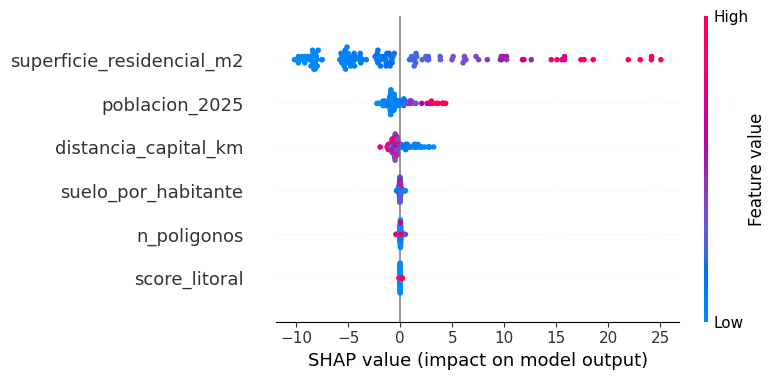

In [ ]:
shap.summary_plot(
    shap_values,
    X
)

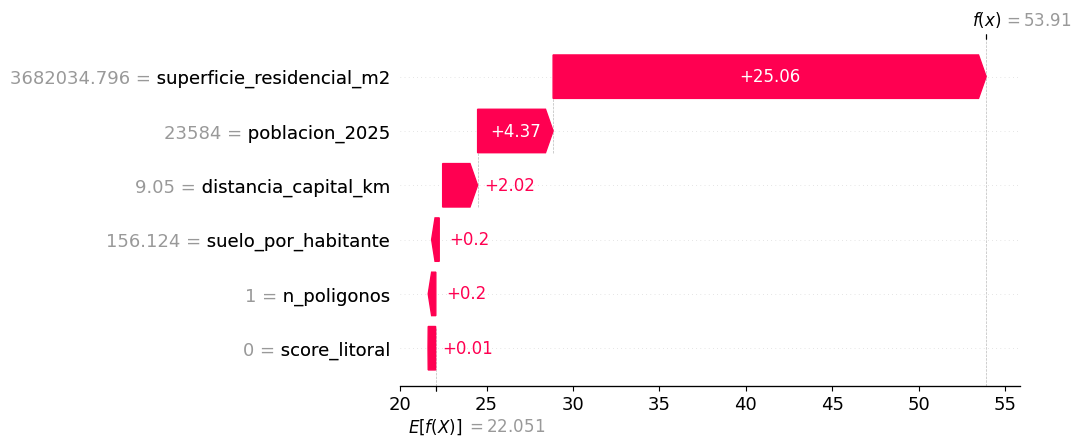

In [ ]:
idx = df_v3[
    df_v3["municipio"] == "Gabias, Las"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

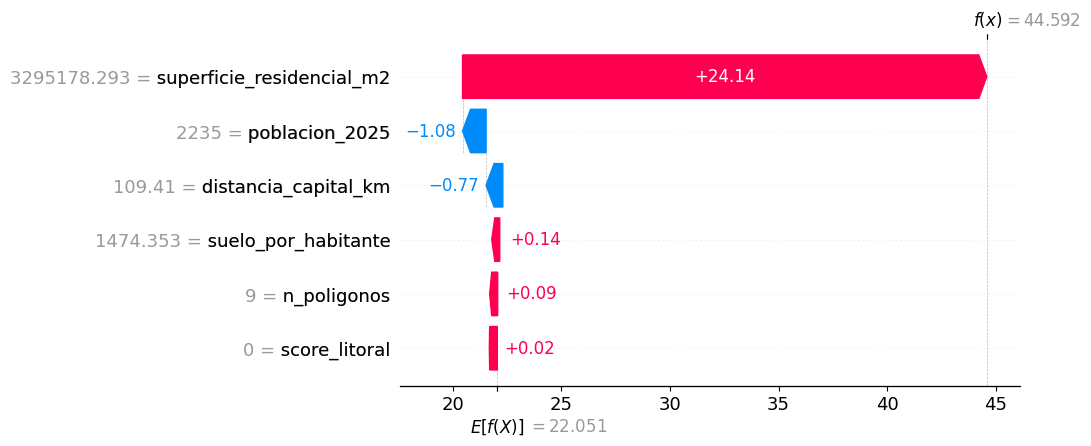

In [ ]:
idx = df_v3[
    df_v3["municipio"] == "Benamaurel"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)



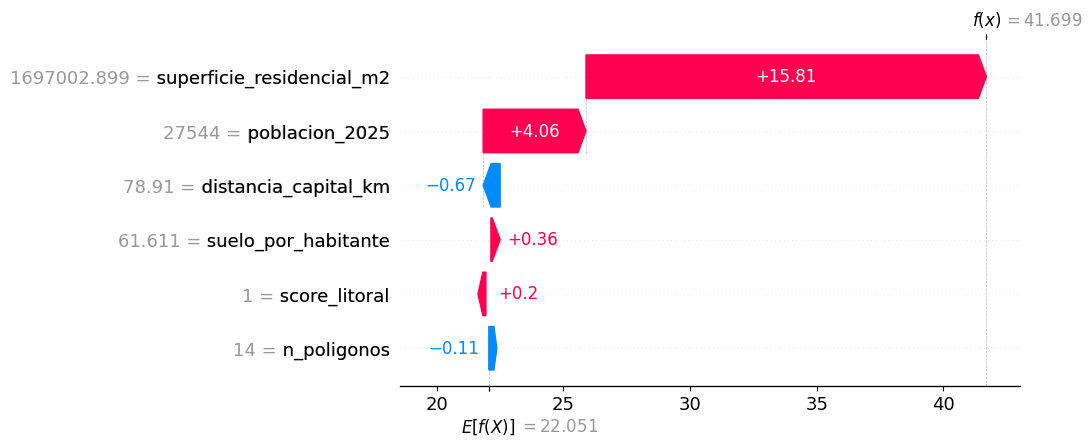

In [ ]:
idx = df_v3[
    df_v3["municipio"] == "Almuñécar"
].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

In [ ]:
df_v3[
    [
        "municipio",
        "poblacion_2025",
        "score_litoral",
        "coopscore_v6"
    ]
].sort_values(
    "coopscore_v6",
    ascending=False
).head(20)

,municipio,poblacion_2025,score_litoral,coopscore_v6
0,"Gabias, Las",23584,0.0,56.101276
2,Atarfe,20914,0.0,51.873899
19,Maracena,22294,0.0,50.230449
6,Salobreña,12760,1.0,49.929300
4,Albolote,19768,0.0,49.472101
3,Benamaurel,2235,0.0,46.202831
9,Armilla,25300,0.0,45.589540
12,Almuñécar,27544,1.0,45.104343
11,Churriana de la Vega,16878,0.0,43.732634
1,Guadix,18881,0.0,42.933646


In [ ]:
importancias = pd.DataFrame({
    "variable": features,
    "importancia": modelo_v6.feature_importances_
})

importancias.sort_values(
    "importancia",
    ascending=False
)

,variable,importancia
1,superficie_residencial_m2,0.472732
0,poblacion_2025,0.437073
4,distancia_capital_km,0.047591
5,score_litoral,0.018001
3,suelo_por_habitante,0.013884
2,n_poligonos,0.010718


In [ ]:
features = [
    "poblacion_2025",
    "superficie_residencial_m2",
    "n_poligonos",
    "suelo_por_habitante",
    "distancia_capital_km",
    "influencia_litoral"
]

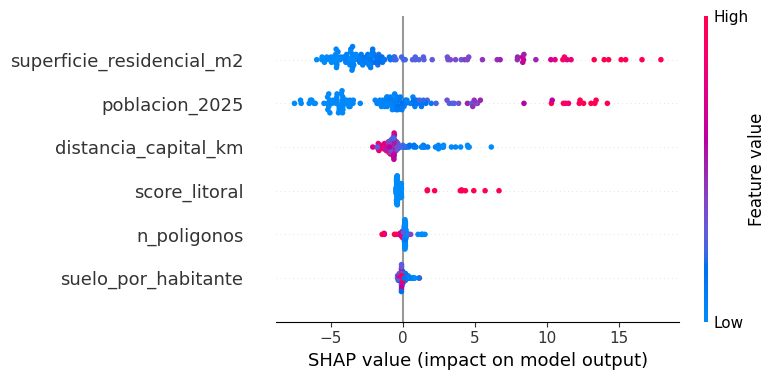

In [ ]:
explainer = shap.TreeExplainer(modelo_v6)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)